In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("[SUCCESS] All required libraries imported successfully!")


[SUCCESS] All required libraries imported successfully!


In [2]:
 # 2. Load dataset and inspect data
df = pd.read_csv("house_prices.csv")

print("=== DATASET INSPECTION ===")
print(f"Dataset Shape (Rows, Columns): {df.shape}")
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\n--- Summary Statistics of Key Numerical Features ---")
print(df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'grade', 'yr_built']].describe())

df.head(3)

=== DATASET INSPECTION ===
Dataset Shape (Rows, Columns): (21613, 21)

--- Missing Values Count ---
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

--- Summary Statistics of Key Numerical Features ---
              price      bedrooms     bathrooms   sqft_living      sqft_lot  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  2.161300e+04   
mean   5.400881e+05      3.370842      2.114757   2079.899736  1.510697e+04   
std    3.671272e+05      0.930062      0.770163    918.440897  4.142051e+04   
min    7.500000e+04      0.000000      0.000000    290.000000  5.200000e+02   
25%    3.219500e+05      3.000000      

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


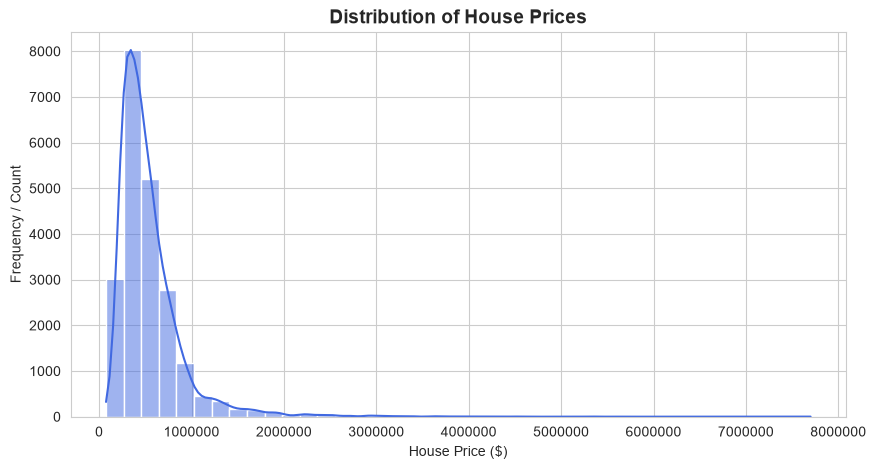

In [3]:
# 3. Target Variable (Price) Distribution Plot
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='royalblue', bins=40)
plt.title("Distribution of House Prices", fontsize=14, fontweight='bold')
plt.xlabel("House Price ($)")
plt.ylabel("Frequency / Count")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

## Feature Selection & Domain Rationale
* **Living Area (`sqft_living`, `sqft_above`, `sqft_basement`):** Square footage is the single strongest driver of real estate valuation. Larger internal living area directly leads to higher baseline market prices.
* **Rooms & Capacity (`bedrooms`, `bathrooms`, `floors`):** Accommodation capacity determines family suitability, directly elevating rental yield and purchasing demand.
* **Construction Quality & View (`grade`, `condition`, `waterfront`, `view`):** Premium architectural grading and scenic waterfront views provide exponential price appreciation.
* **Age & Renovation (`house_age`, `is_renovated`):** Older non-renovated houses depreciate in value due to maintenance overheads, whereas renovated properties maintain higher market demand.
* **Geographical Location (`lat`, `long`, `zipcode`):** Proximity to economic hubs and high-tier neighborhoods strongly dictates property valuation.

In [4]:
# 5. Feature Engineering & One-Hot Encoding
# Calculate house age from year built
df['house_age'] = 2015 - df['yr_built']
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# Drop redundant identifier and date columns
cols_to_drop = ['id', 'date', 'yr_built', 'yr_renovated']
df_processed = df.drop(columns=cols_to_drop)

# One-Hot Encoding for categorical features ('waterfront', 'condition')
df_encoded = pd.get_dummies(df_processed, columns=['waterfront', 'condition'], drop_first=True)

print("=== PREPROCESSING & ENCODING COMPLETE ===")
print(f"Encoded Dataset Shape: {df_encoded.shape}")
df_encoded.head(3)

=== PREPROCESSING & ENCODING COMPLETE ===
Encoded Dataset Shape: (21613, 22)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,grade,sqft_above,sqft_basement,...,long,sqft_living15,sqft_lot15,house_age,is_renovated,waterfront_Y,condition_Fair,condition_Good,condition_Poor,condition_Very Good
0,221900.0,3,1.00,1180,5650,1.0,0,7,1180,0,...,-122.257,1340,5650,60,0,False,False,False,False,False
1,538000.0,3,2.25,2570,7242,2.0,0,7,2170,400,...,-122.319,1690,7639,64,1,False,False,False,False,False
2,180000.0,2,1.00,770,10000,1.0,0,6,770,0,...,-122.233,2720,8062,82,0,False,False,False,False,False


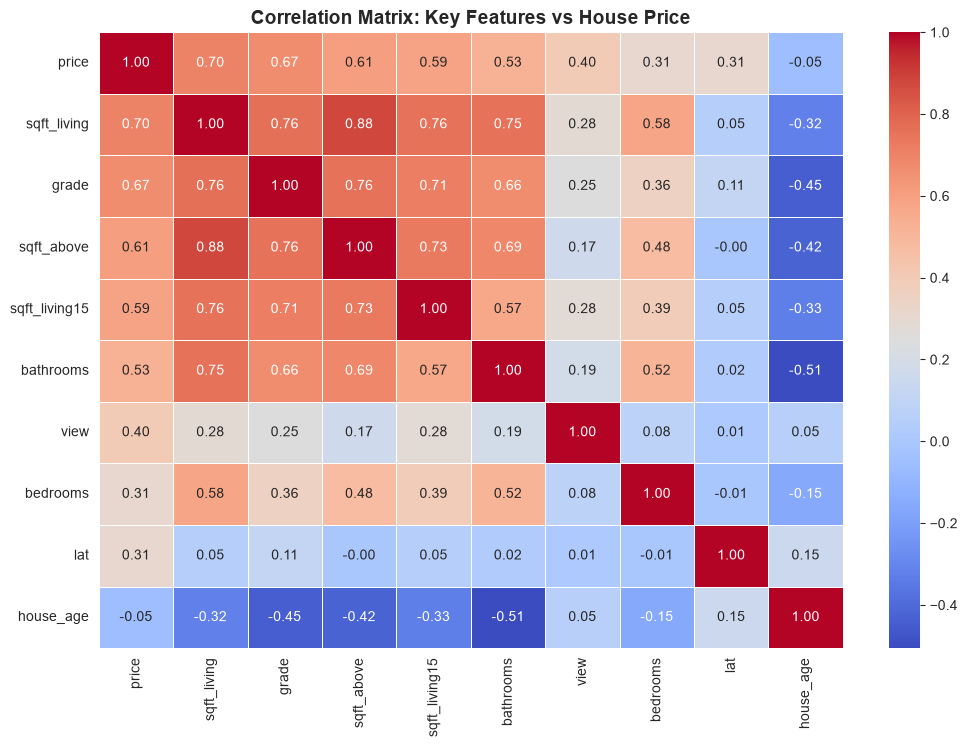

In [5]:
# 6. Correlation Heatmap: Top Features vs House Price
plt.figure(figsize=(12, 8))
key_corr_cols = ['price', 'sqft_living', 'grade', 'sqft_above', 'sqft_living15', 'bathrooms', 'view', 'bedrooms', 'lat', 'house_age']
corr_matrix = df_encoded[key_corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Key Features vs House Price", fontsize=14, fontweight='bold')
plt.show()

In [6]:
# 7. Train/Test Split (80% Training, 20% Testing)
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("=== TRAIN-TEST SPLIT (80/20) ===")
print(f"Training set features shape: {X_train.shape}")
print(f"Testing set features shape:  {X_test.shape}")

=== TRAIN-TEST SPLIT (80/20) ===
Training set features shape: (17290, 21)
Testing set features shape:  (4323, 21)


In [7]:
# 8. Train Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = lr_model.predict(X_test)
print("[SUCCESS] Linear Regression model trained successfully!")

[SUCCESS] Linear Regression model trained successfully!


In [8]:
# 9. Model Evaluation Metrics (MSE, RMSE, R² Score)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== LINEAR REGRESSION EVALUATION METRICS ===")
print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE):  ${rmse:,.2f}")
print(f"R² Score (Accuracy/Variance):   {r2:.4f} ({r2*100:.2f}%)")

=== LINEAR REGRESSION EVALUATION METRICS ===
Mean Squared Error (MSE):       45,124,564,987.91
Root Mean Squared Error (RMSE):  $212,425.43
R² Score (Accuracy/Variance):   0.7015 (70.15%)


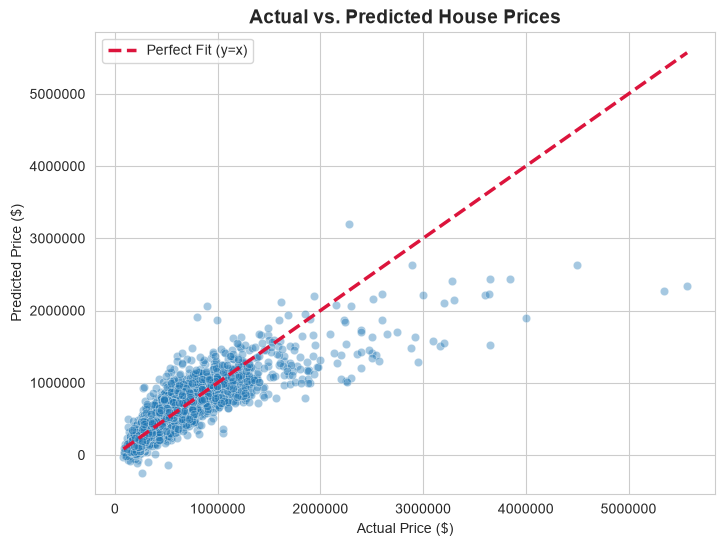

In [9]:
# 10. Scatter Plot: Actual Prices vs Predicted Prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='#1f77b4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', linestyle='--', linewidth=2.5, label='Perfect Fit (y=x)')
plt.title("Actual vs. Predicted House Prices", fontsize=14, fontweight='bold')
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.show()

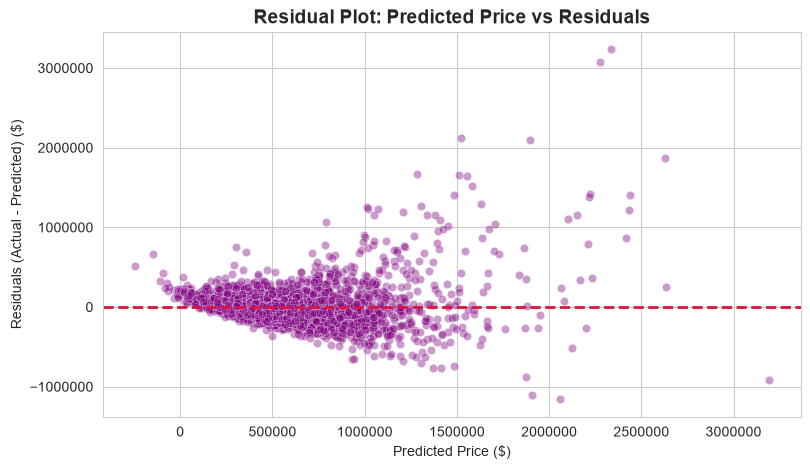

In [10]:
# 11. Residual Plot (Checking Error Randomness)
residuals = y_test - y_pred

plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_pred, y=residuals, color='purple', alpha=0.4)
plt.axhline(0, color='crimson', linestyle='--', linewidth=2)
plt.title("Residual Plot: Predicted Price vs Residuals", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals (Actual - Predicted) ($)")
plt.ticklabel_format(style='plain', axis='both')
plt.show()

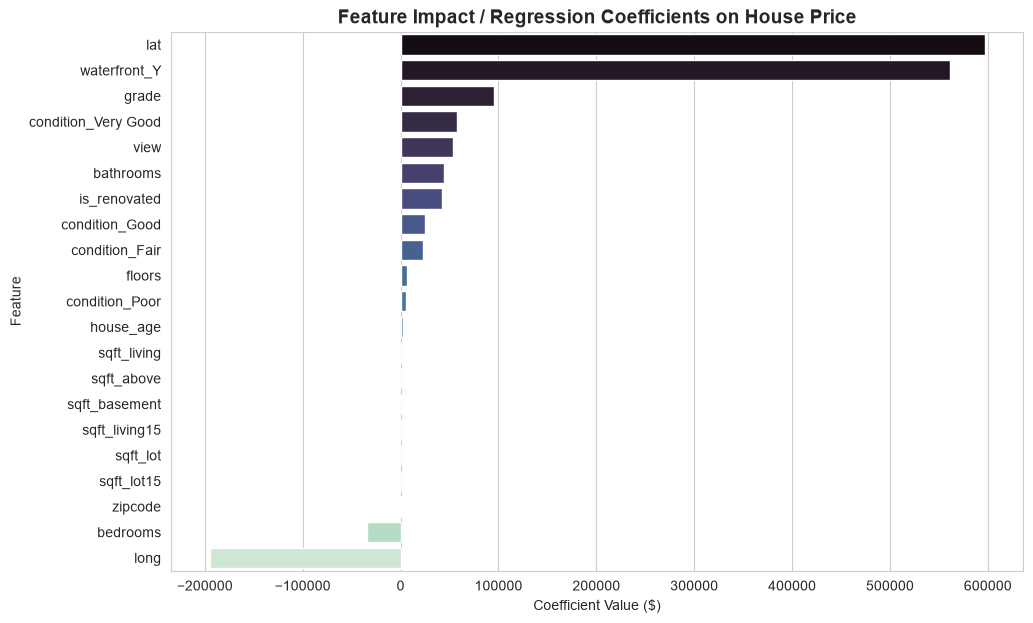

,Feature,Coefficient
10,lat,596784.240897
16,waterfront_Y,561724.175607
6,grade,95059.125174
20,condition_Very Good,57326.813560
5,view,53633.029984
1,bathrooms,44239.583649
15,is_renovated,42159.488586
18,condition_Good,24765.382560
17,condition_Fair,23268.773421
4,floors,6944.266116


In [12]:
# 12. Feature Coefficient Analysis (Positive & Negative Impact)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(11, 7))
# Updated with hue='Feature' and legend=False to fix future warning
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title("Feature Impact / Regression Coefficients on House Price", fontsize=14, fontweight='bold')
plt.xlabel("Coefficient Value ($)")
plt.show()

coef_df

In [13]:
# 13. Bonus: Compare Linear Regression vs. Ridge and Lasso Regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression (L2)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

# Lasso Regression (L1)
lasso_model = Lasso(alpha=100.0)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

# Comparison Summary Table
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression (OLS)", "Ridge Regression (L2)", "Lasso Regression (L1)"],
    "R² Score": [f"{r2:.4f}", f"{ridge_r2:.4f}", f"{lasso_r2:.4f}"],
    "RMSE ($)": [f"${rmse:,.2f}", f"${ridge_rmse:,.2f}", f"${lasso_rmse:,.2f}"]
})

print("=== REGULARIZATION MODEL COMPARISON SUMMARY ===")
print(comparison_df.to_string(index=False))

=== REGULARIZATION MODEL COMPARISON SUMMARY ===
                  Model R² Score    RMSE ($)
Linear Regression (OLS)   0.7015 $212,425.43
  Ridge Regression (L2)   0.7015 $212,433.53
  Lasso Regression (L1)   0.7014 $212,460.17
